#  Phase 1 — SOLUTION — Data Cleaning & Feature Engineering
### EEIA 2025 — Analyse de Survie & Médecine de Précision

> ⚠️ **Document réservé aux encadrants. Ne pas distribuer aux étudiants avant la fin de la session.**

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 50)

## Important Information

| Variable                        | Description                                                                                                         | Type                 |
| ------------------------------- | ------------------------------------------------------------------------------------------------------------------- | -------------------- |
| `Study ID`                      | Identifiant de l’étude clinique ou génomique.                                                                       | Catégorielle         |
| `Patient ID`                    | Identifiant unique du patient. Plusieurs échantillons peuvent appartenir au même patient.                           | Catégorielle         |
| `Sample ID`                     | Identifiant unique de l’échantillon tumoral séquencé.                                                               | Catégorielle         |
| `Cancer Type`                   | Type général de cancer diagnostiqué chez le patient.                                                                | Catégorielle         |
| `Cancer Type Detailed`          | Sous-type histologique détaillé du cancer du sein.                                                                  | Catégorielle         |
| `Ethnicity`                     | Origine ethnique déclarée du patient.                                                                               | Catégorielle         |
| `Fraction Genome Altered`       | Proportion du génome présentant des altérations génétiques (copy number alterations). Valeur comprise entre 0 et 1. | Numérique continue   |
| `Sex`                           | Sexe biologique du patient.                                                                                         | Catégorielle         |
| `Gene Panel`                    | Panel de gènes utilisé pour le séquençage (IMPACT341, IMPACT410, etc.).                                             | Catégorielle         |
| `Metastatic Site`               | Organe ou site anatomique où la métastase a été détectée.                                                           | Catégorielle         |
| `MSI Comment`                   | Commentaire clinique/interprétation concernant le statut MSI.                                                       | Texte                |
| `MSI Score`                     | Score numérique mesurant l’instabilité des microsatellites (Microsatellite Instability).                            | Numérique continue   |
| `MSI Type`                      | Catégorie du statut MSI (Stable, Instable, Indeterminate…).                                                         | Catégorielle         |
| `Mutation Count`                | Nombre total de mutations somatiques détectées dans l’échantillon tumoral.                                          | Numérique discrète   |
| `Oncotree Code`                 | Code normalisé décrivant le sous-type tumoral selon la classification OncoTree.                                     | Catégorielle         |
| `Overall Survival (Months)`     | Temps de survie globale du patient en mois après diagnostic ou suivi.                                               | Numérique continue   |
| `Overall Survival Status`       | Statut de survie du patient au dernier suivi (vivant/décédé).                                                       | Catégorielle binaire |
| `Primary Tumor Site`            | Site anatomique primaire de la tumeur.                                                                              | Catégorielle         |
| `Race`                          | Groupe racial déclaré du patient.                                                                                   | Catégorielle         |
| `Sample Class`                  | Classe de l’échantillon analysé (ex. Tumor).                                                                        | Catégorielle         |
| `Number of Samples Per Patient` | Nombre total d’échantillons disponibles pour un même patient.                                                       | Numérique discrète   |
| `Sample coverage`               | Profondeur de séquençage de l’échantillon (coverage).                                                               | Numérique discrète   |
| `Sample Type`                   | Type d’échantillon analysé : tumeur primaire, métastase, récidive locale, etc.                                      | Catégorielle         |
| `Somatic Status`                | Indique si les mutations ont été identifiées avec un échantillon normal apparié (Matched/Unmatched).                | Catégorielle         |
| `Tumor Purity`                  | Pourcentage estimé de cellules tumorales dans l’échantillon.                                                        | Numérique continue   |


## SOLUTION Exercice 1 : Parser la variable cible

In [41]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [18]:
DATA_PATH = "/content/drive/MyDrive/EEIA_2026/fichier_py/breast_msk_2025_clinical_data.tsv" # Remplacer cette ligne par l'emplacement de votre fichier
df_raw = pd.read_csv(DATA_PATH, sep="\t", low_memory=False)
print(f"Dimensions : {df_raw.shape}")
df_raw.head(3)

Dimensions : (3879, 25)


,Study ID,Patient ID,Sample ID,Cancer Type,Cancer Type Detailed,Ethnicity,Fraction Genome Altered,Sex,Gene Panel,Metastatic Site,MSI Comment,MSI Score,MSI Type,Mutation Count,Oncotree Code,Overall Survival (Months),Overall Survival Status,Primary Tumor Site,Race,Sample Class,Number of Samples Per Patient,Sample coverage,Sample Type,Somatic Status,Tumor Purity
0,breast_msk_2025,P-0000004,P-0000004-T01-IM3,Breast Cancer,Breast Invasive Ductal Carcinoma,Non-Spanish; Non-Hispanic,0.2782,FEMALE,IMPACT341,NaN,MICROSATELLITE STABLE (MSS). See MSI note below.,2.50,Stable,4.0,IDC,3.550646,1:DECEASED,Breast,WHITE,Tumor,1,428,Primary,Matched,50
1,breast_msk_2025,P-0000012,P-0000012-T02-IM3,Breast Cancer,Breast Invasive Ductal Carcinoma,Non-Spanish; Non-Hispanic,0.3146,Female,IMPACT341,NaN,MICROSATELLITE INSTABILITY-INDETERMINATE. See ...,4.10,Indeterminate,1.0,IDC,132.656081,0:LIVING,Breast,White,Tumor,1,344,Primary,Matched,NaN
2,breast_msk_2025,P-0000015,P-0000015-T01-IM3,Breast Cancer,Breast Invasive Ductal Carcinoma,Non-Spanish; Non-Hispanic,0.3503,FEMALE,IMPACT341,Liver,NaN,2.55,Stable,7.0,IDC,13.676562,1:DECEASED,Breast,WHITE,Tumor,1,281,Metastasis,Matched,40


In [7]:
print(df_raw.dtypes) # Le faire permet de faire un check par rapport au type de données et de s'assurer que les types correspondent bien au vu de la définition de la var.

Study ID                          object
Patient ID                        object
Sample ID                         object
Cancer Type                       object
Cancer Type Detailed              object
Ethnicity                         object
Fraction Genome Altered          float64
Sex                               object
Gene Panel                        object
Metastatic Site                   object
MSI Comment                       object
MSI Score                        float64
MSI Type                          object
Mutation Count                   float64
Oncotree Code                     object
Overall Survival (Months)        float64
Overall Survival Status           object
Primary Tumor Site                object
Race                              object
Sample Class                      object
Number of Samples Per Patient      int64
Sample coverage                    int64
Sample Type                       object
Somatic Status                    object
Tumor Purity    

In [27]:
print(df_raw.describe())

       Fraction Genome Altered    MSI Score  Mutation Count  \
count              3841.000000  3786.000000     3784.000000   
mean                  0.281697     0.957810        6.096195   
std                   0.189415     1.658486        6.619626   
min                   0.000000    -1.000000        1.000000   
25%                   0.129200     0.080000        3.000000   
50%                   0.253800     0.440000        5.000000   
75%                   0.406900     1.240000        7.000000   
max                   0.981400    46.130000      179.000000   

       Overall Survival (Months)  Number of Samples Per Patient  \
count                3871.000000                    3879.000000   
mean                   46.118694                       1.469709   
std                    33.945864                       0.723187   
min                     0.000000                       1.000000   
25%                    15.188875                       1.000000   
50%                    40.1091

In [8]:
df = df_raw.copy()

# Approche 1 : avec str.contains (robuste)
df['event'] = df['Overall Survival Status'].str.contains('DECEASED', na=False).astype(int)

# Approche 2 : avec apply (lisible)
# df['event'] = df['Overall Survival Status'].apply(lambda x: 1 if 'DECEASED' in str(x) else 0)

print(df['event'].value_counts())
print(f"Taux d'événements : {df['event'].mean():.1%}")

event
1    2140
0    1739
Name: count, dtype: int64
Taux d'événements : 55.2%


##  SOLUTION Exercice 2 : Variable temporelle

In [9]:
df['Overall Survival (Months)'] = pd.to_numeric(df['Overall Survival (Months)'], errors='coerce')

print(df['Overall Survival (Months)'].describe().round(1))
print(f"\nManquants : {df['Overall Survival (Months)'].isnull().sum()}") # ou isna.sum()

count    3871.0
mean       46.1
std        33.9
min         0.0
25%        15.2
50%        40.1
75%        74.8
max       132.7
Name: Overall Survival (Months), dtype: float64

Manquants : 8


## SOLUTION Exercice 3 : Valeurs manquantes

In [10]:
# 1. Metastatic Site → imputation par 'Unknown'
if 'Metastatic Site' in df.columns:
    df['Metastatic Site'] = df['Metastatic Site'].fillna('Unknown')

# 2. Tumor Purity — analyse
if 'Tumor Purity' in df.columns:
    print("Tumor Purity :")
    print(df['Tumor Purity'].dtype)
    df['Tumor Purity'] = pd.to_numeric(df['Tumor Purity'], errors='coerce')
    print(df['Tumor Purity'].describe().round(3))
    print(f"Manquants : {df['Tumor Purity'].isnull().sum()} ({df['Tumor Purity'].isnull().mean():.1%})")

    # Stratégie recommandée : imputation par médiane
    # (distribution relativement symétrique, pas d'outliers extrêmes)
    median_purity = df['Tumor Purity'].median()
    df['Tumor Purity'] = df['Tumor Purity'].fillna(median_purity)
    print(f"\nImputation par médiane : {median_purity:.3f}")




# 3. Mutation Count → numérique
df['Mutation Count'] = pd.to_numeric(df['Mutation Count'], errors='coerce')
print(f"\nMutation Count - manquants après conversion : {(df['Mutation Count'].isnull().sum())/df.shape[0]}")

Tumor Purity :
object
count    3795.000
mean       43.640
std        18.746
min         5.000
25%        30.000
50%        40.000
75%        60.000
max        95.000
Name: Tumor Purity, dtype: float64
Manquants : 84 (2.2%)

Imputation par médiane : 40.000

Mutation Count - manquants après conversion : 0.024490848156741428


In [11]:
#Missing values in Mutation Count represented only 2.45% of samples. Since mutation burden may vary according to sequencing panel coverage, missing values were imputed using the median Mutation Count within each Gene Panel subgroup.

df['MutationCount_missing'] = df['Mutation Count'].isna().astype(int)
df['Mutation Count'] = (
    df.groupby('Gene Panel')['Mutation Count']
      .transform(lambda x: x.fillna(x.median()))
)
df['Mutation Count'].isna().sum()

np.int64(0)

##  SOLUTION Exercice 4 : Feature Engineering

In [12]:
# is_metastatic
df['is_metastatic'] = (df['Sample Type'] == 'Metastasis').astype(int)

# FGA_high
df['FGA_high'] = (df['Fraction Genome Altered'] >= 0.2).astype(int)

print("Sample Type distribution :")
print(df[['Sample Type', 'is_metastatic']].value_counts())

print("\nFGA_high distribution :")
print(df['FGA_high'].value_counts())

Sample Type distribution :
Sample Type       is_metastatic
Metastasis        1                2050
Primary           0                1812
Local Recurrence  0                  11
Unknown           0                   6
Name: count, dtype: int64

FGA_high distribution :
FGA_high
1    2341
0    1538
Name: count, dtype: int64


#### Exploration

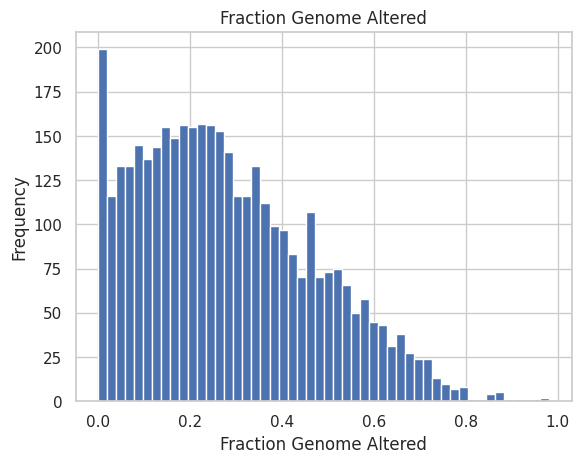

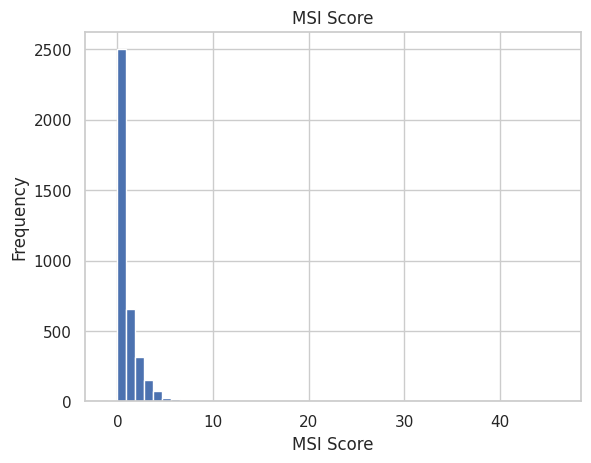

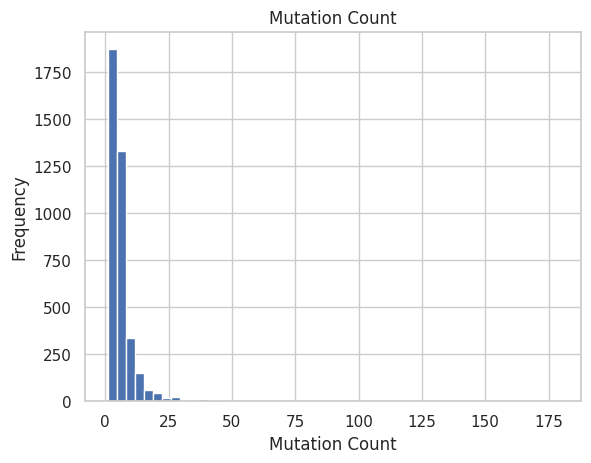

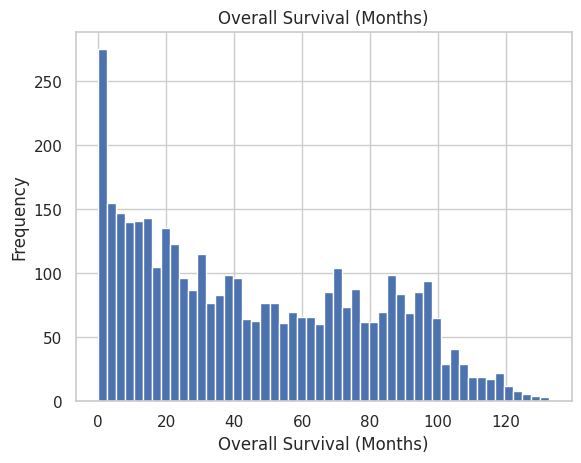

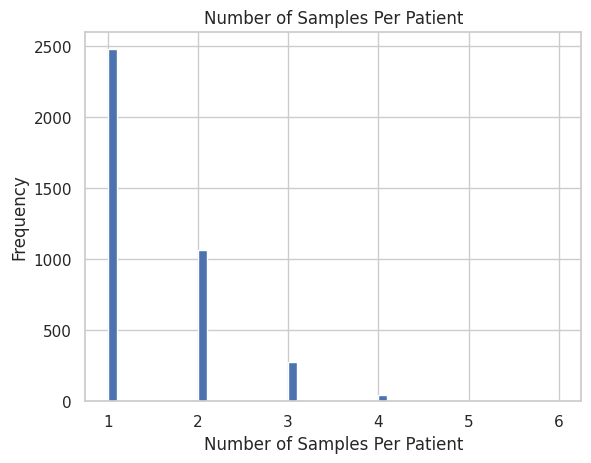

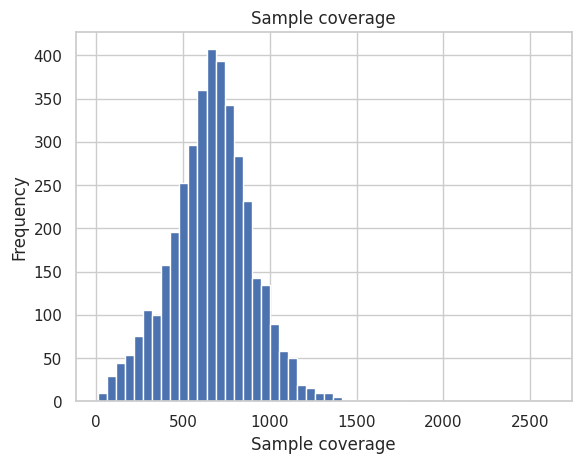

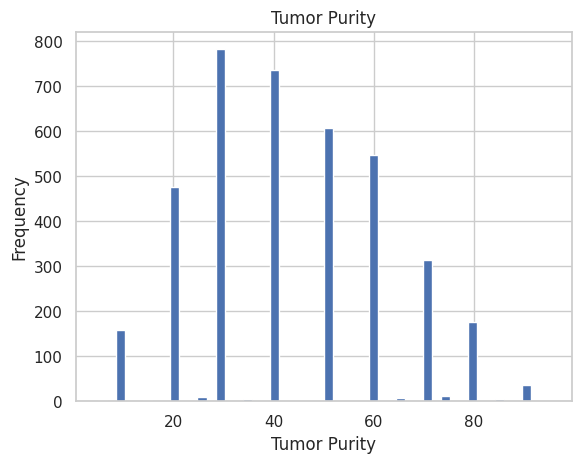

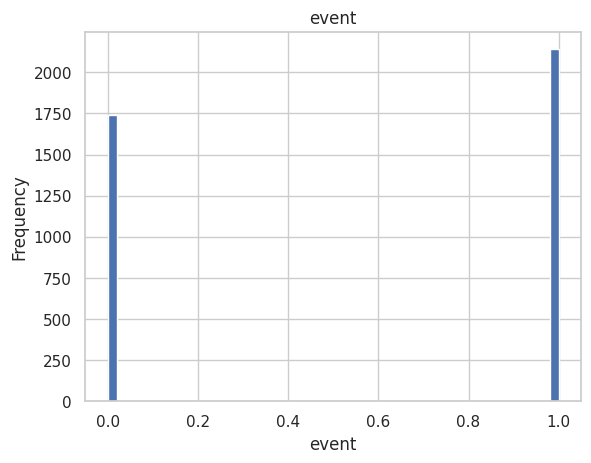

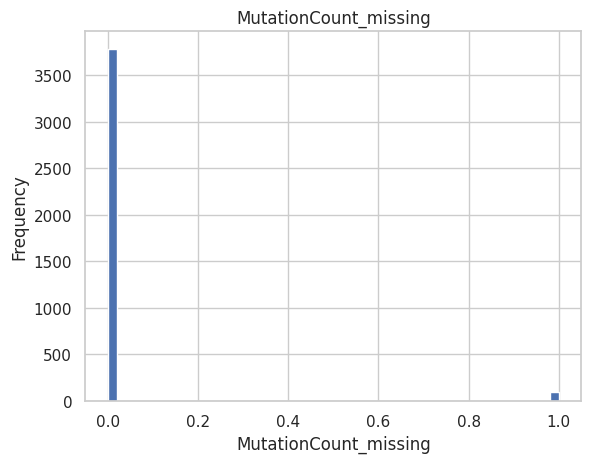

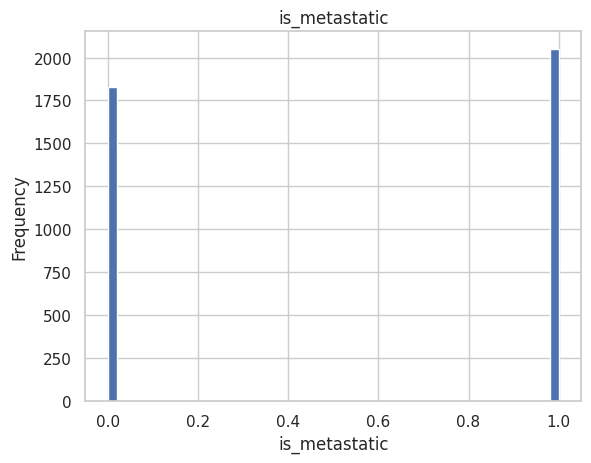

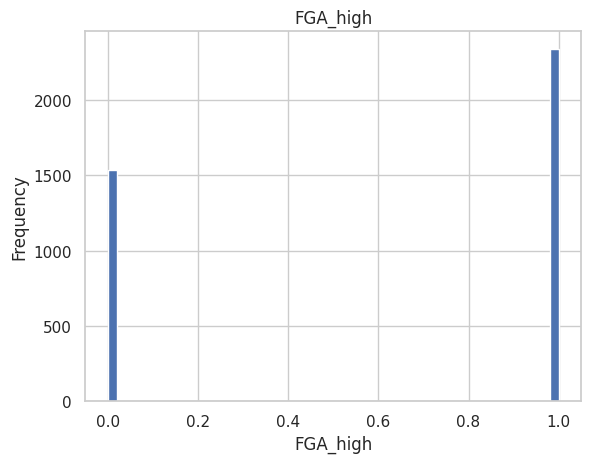

In [28]:
for col in df.select_dtypes(include=['int64', 'float64']):

    plt.figure()
    df[col].hist(bins=50)
    plt.title(col)
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

In [34]:
df.groupby('Overall Survival Status')['Overall Survival (Months)'].describe()

,count,mean,std,min,25%,50%,75%,max
Overall Survival Status,,,,,,,,
0:living,1731.0,66.417163,34.035811,0.0,48.426867,73.873163,92.316797,132.656081
1:deceased,2140.0,29.699698,23.340288,0.0,11.243712,23.851793,41.637900,123.647960
nan,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


<Axes: title={'center': 'Overall Survival (Months)'}, xlabel='Overall Survival Status'>

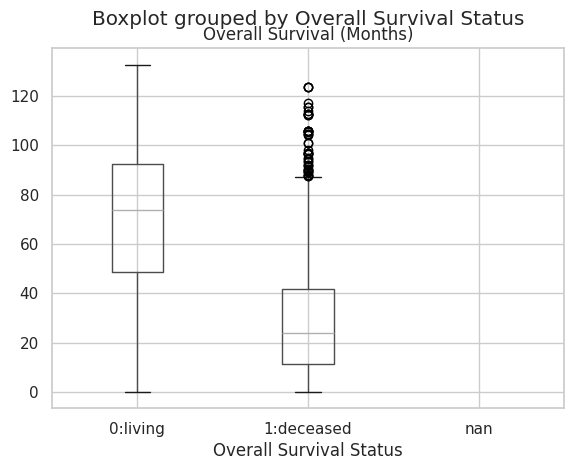

In [35]:
df.boxplot(column='Overall Survival (Months)', by='Overall Survival Status')

# Regarder le boxplot suivant en fonction juste du sample ID

In [22]:
# Normalisation des colonnes texte
for col in df.select_dtypes(include='object').columns:

    df[col] = (
        df[col]
        .astype(str)          # convertit en string
        .str.strip()          # enlève les espaces avant/après
        .str.lower()          # met en minuscules
    )


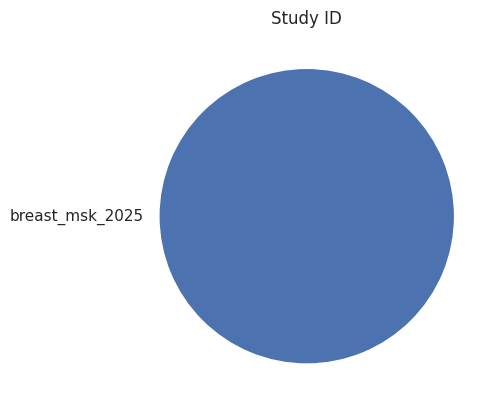

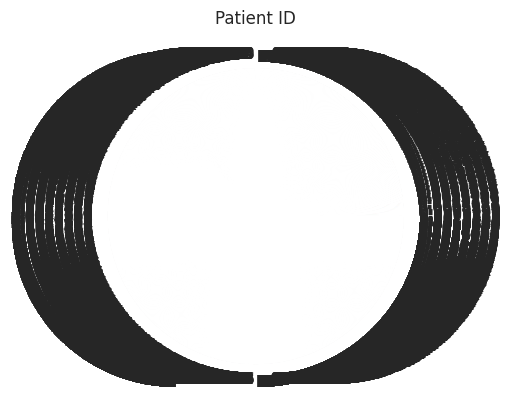

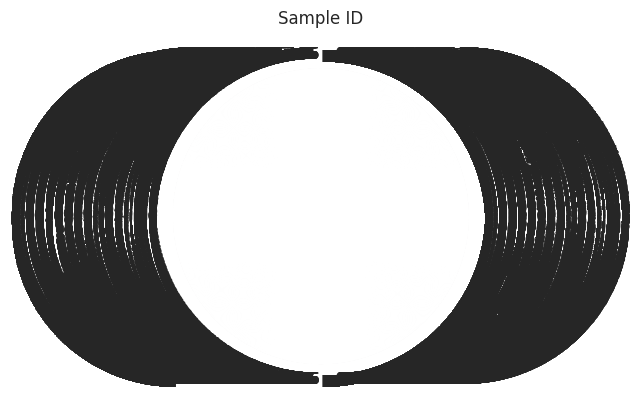

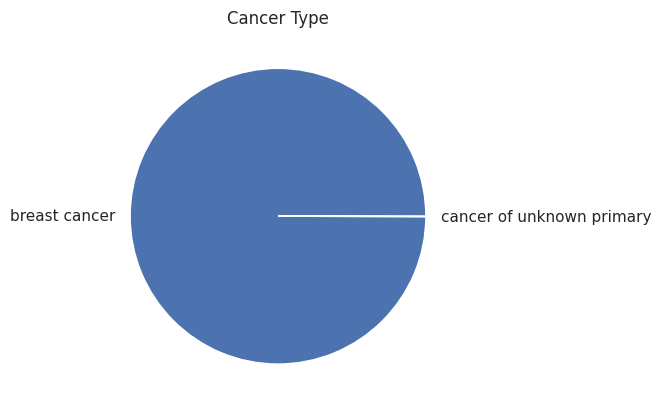

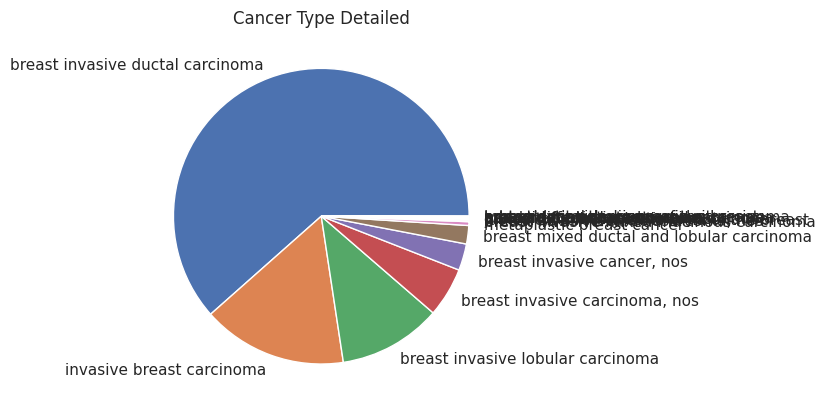

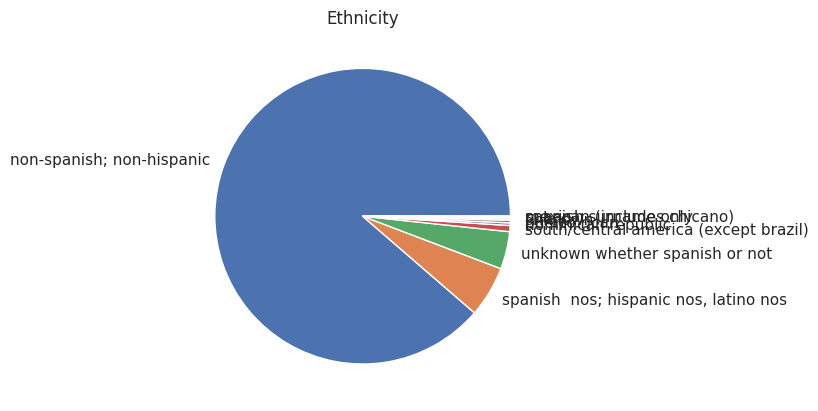

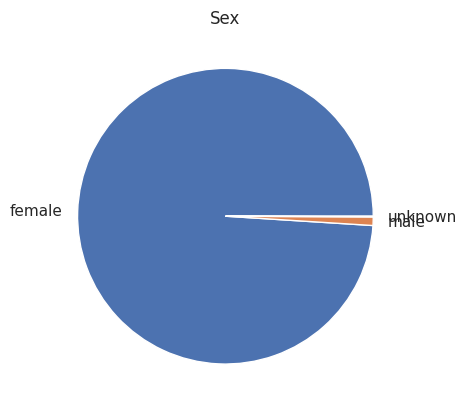

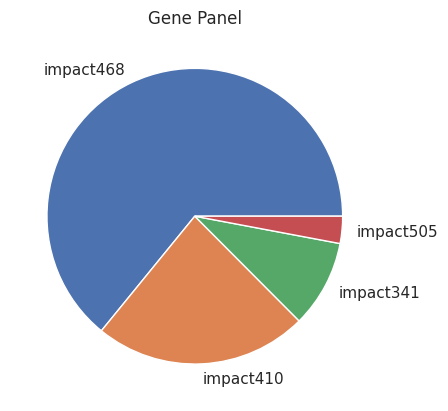

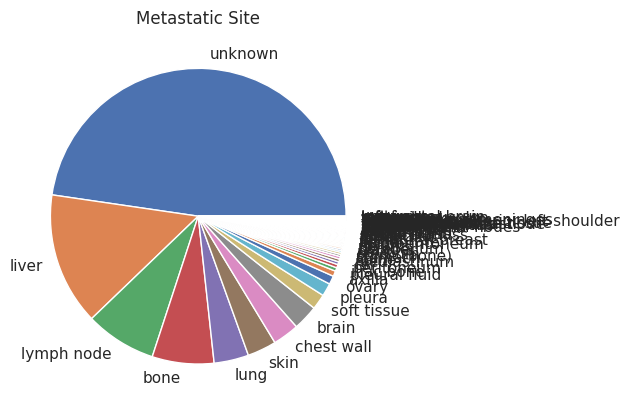

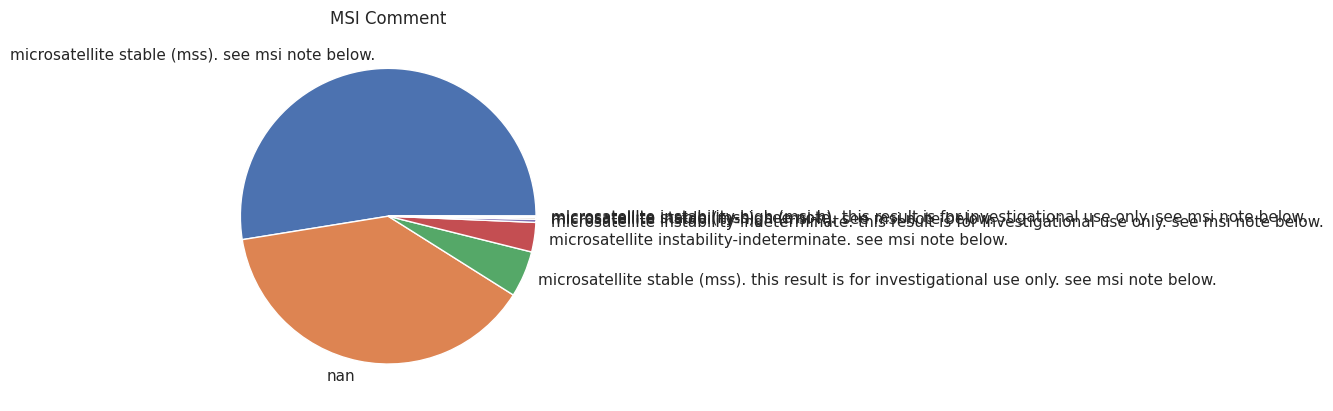

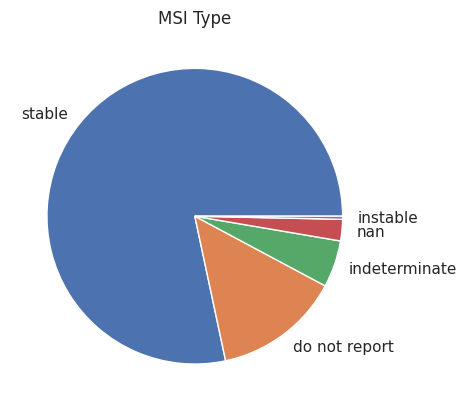

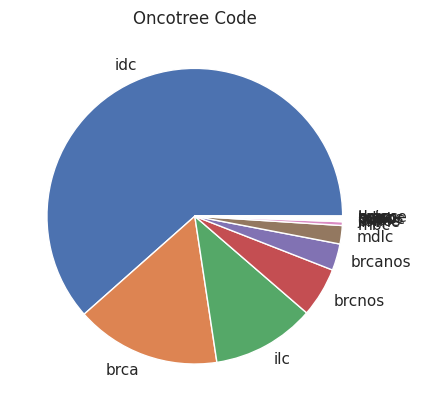

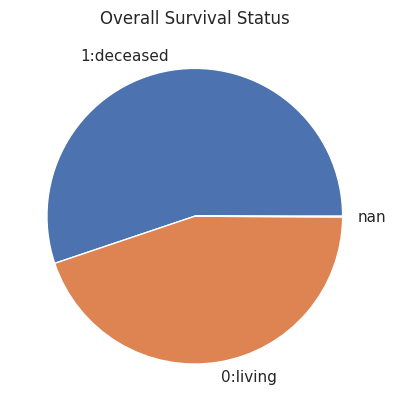

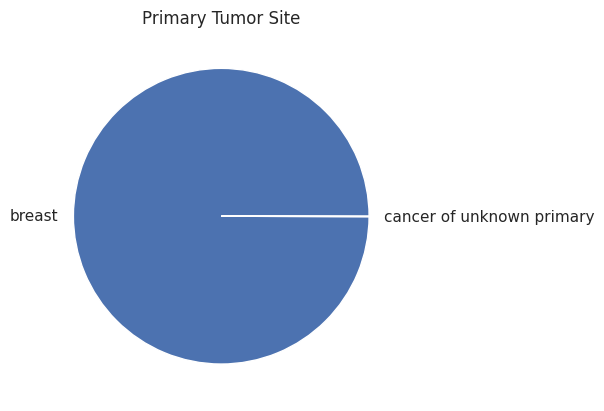

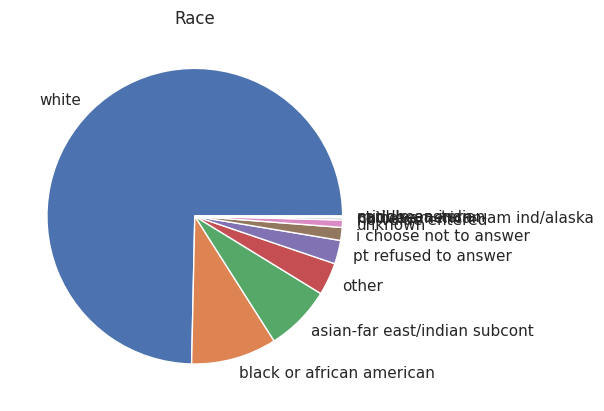

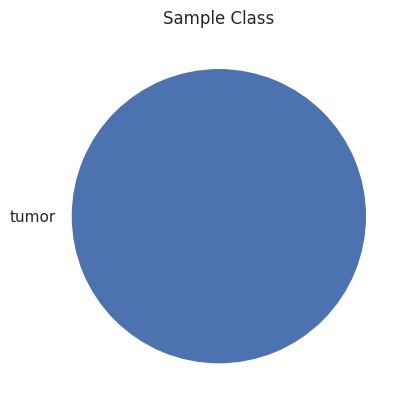

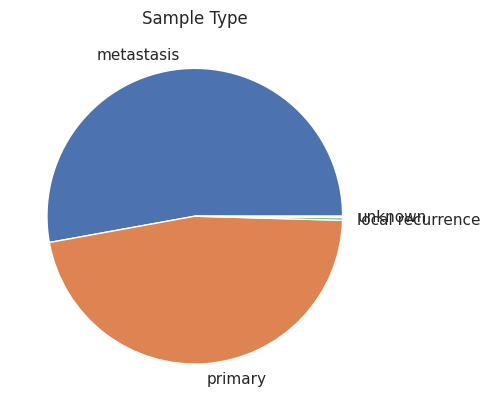

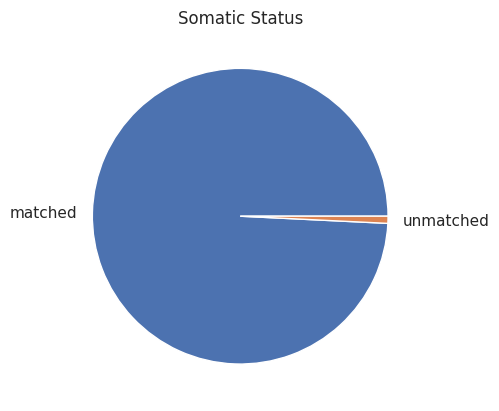

In [23]:

for col in df.select_dtypes('object'):
  plt.figure()
  df[col].value_counts().plot.pie()

  plt.title(col)
  plt.ylabel('')

  plt.show()

### Observations issues de l’analyse exploratoire
- Certaines colonnes (Study ID, Sample Class) sont constantes et n’apportent pas d’information discriminante.
- Plusieurs variables catégorielles présentaient des incohérences d’écriture (FEMALE/female, WHITE/white) qui ont été normalisées.
- Certaines variables présentent un fort déséquilibre de classes (Sex, MSI Type, Somatic Status).
- Des catégories rares ont été identifiées dans Metastatic Site, Race et Cancer Type Detailed.
- Les colonnes identifiantes (Patient ID, Sample ID) seront exclues des analyses prédictives afin d’éviter toute fuite d’information.
- MSI Comment contient une information redondante avec MSI Type et pourra être supprimée.

In [25]:
df.drop(columns=['Study ID', 'Sample Class', 'Patient ID', 'Sample ID','MSI Comment'], inplace=True) # On peut-être tenté de retirer la variable sex en raison du type de cancer et du déséquilibre dans les données. Mais, il faut y faire gaffe, en biologie cette variable malgré son déséquilibre peut-être associée à la survie de l'individu.


top_sites = df['Metastatic Site'].value_counts().nlargest(10).index

df['Metastatic Site'] = df['Metastatic Site'].apply(
    lambda x: x if x in top_sites else 'other'
)



replace_dict = {
    'no value entered': 'unknown',
    'pt refused to answer': 'unknown',
    'i choose not to answer': 'unknown'
}

df['Race'] = df['Race'].replace(replace_dict)



### 1. Profil génomique global de la cohorte

####  Mutation Count

* La grande majorité des patients présente une **faible charge mutationnelle** (principalement dans le premier bin).
* Une petite fraction de patients présente une **charge mutationnelle très élevée** (long tail → hypermutateurs).

Conclusion :

* Distribution fortement asymétrique (skewed)
* Présence de sous-populations biologiques distinctes
* Phénomène classique en oncologie

---

####  MSI Score (Microsatellite Instability)

* Très forte concentration sur des valeurs faibles.
* La majorité des tumeurs sont **microsatellite stables (MSS)**.
* Très peu de cas MSI-H (instables).

Conclusion :

* Cohorte dominée par des tumeurs MSS
* MSI-H = sous-groupe rare mais biologiquement important

---

####  Fraction Genome Altered (FGA)

* Distribution progressive avec une majorité de valeurs faibles à modérées.
* Quelques patients présentent une forte altération génomique (> 0.5).

Conclusion :

* Hétérogénéité génomique importante
* Présence de tumeurs fortement instables chromosomiquement

---

### 2. Variables cliniques et de survie

####  Overall Survival (Months)

* Distribution étalée de 0 à ~130 mois.
* Pic de fréquence au début de la courbe.
* Longue queue vers les survies élevées.

Conclusion :

* Forte variabilité des durées de survie
* Présence de données censurées (patients encore vivants)



####  Overall Survival Status (analyse croisée)

* Patients décédés : survie médiane ≈ **23 mois**
* Patients vivants : survie médiane ≈ **74 mois**

Conclusion :

* Séparation très nette entre les deux groupes
* Le signal de survie est fort et exploitable
* Cohérence biologique confirmée

---

####  Event (décès / vivant)

* Légère majorité de décès dans la cohorte.




---

### 3. Structure des échantillons et qualité des données

#### Number of Samples Per Patient

* Majorité des patients avec un seul échantillon.
* Quelques cas avec 2 à 6 échantillons.

Conclusion :

* Dataset principalement longitudinal faible
* Structure simple et standard

---

#### Sample Coverage

* Distribution globalement normale centrée autour de 600–800x.
* Quelques valeurs extrêmes rares.

Conclusion :

* Qualité de séquençage globalement robuste
* Quelques variations techniques attendues

---

#### Tumor Purity

* Distribution centrée entre 30% et 70%.
* Présence de groupes distincts.

Conclusion :

* Hétérogénéité tumorale importante
* Mesure influencée à la fois biologiquement et techniquement

---

### 4. Variables binaires et catégorielles

#### is_metastatic

* Légère prédominance des cas métastatiques.



---

#### FGA_high

* Plus de patients classés “FGA élevé”.


---

#### MutationCount_missing

* Très peu de valeurs manquantes.

Conclusion :

* Donnée fiable, peu d’imputation nécessaire

---

#### 5. Synthèse globale

La cohorte étudiée présente les caractéristiques suivantes :

* Forte hétérogénéité génomique (Mutation Count, FGA, MSI)
* Majorité de tumeurs microsatellites stables (MSS)
* Présence de sous-populations hypermutées rares mais importantes
* Données de survie bien structurées avec un signal fort entre vivants et décédés
* Cohorte enrichie en cas métastatiques (stades avancés)
* Données globalement propres et exploitables pour du machine learning

---

### 6. Conclusion générale (version “rapport / notebook”)

Cette analyse exploratoire met en évidence une cohorte de cancer du sein caractérisée par une forte hétérogénéité génomique et clinique. Les distributions des variables clés (Mutation Count, MSI Score et Fraction Genome Altered) révèlent des profils fortement asymétriques, typiques des données en oncologie. Les analyses de survie montrent une séparation nette entre patients décédés et patients vivants, confirmant la pertinence biologique des variables de survie. La cohorte est globalement enrichie en cas métastatiques et en tumeurs génétiquement instables, ce qui en fait un jeu de données adapté à des analyses de survie et de modélisation prédictive.



In [44]:
# Sauvegarde
df.to_csv('cleaned_data.csv', index=False)

## 💡 Notes pédagogiques pour l'encadrant

### Points d'attention fréquents
- Certains étudiants vont vouloir supprimer les censurés → expliquer pourquoi c'est une erreur fondamentale
- Le choix entre imputation et suppression pour `Tumor Purity` n'a pas de bonne/mauvaise réponse : l'important est la justification
- `pd.to_numeric(errors='coerce')` vs `astype(float)` : le premier est plus sûr sur données réelles

### Réponses aux questions de réflexion
1. Supprimer les censurés biaiserait l'analyse : on ne garderait que les morts, surestimant le risque
2. La proportion dépend du dataset (explorer !). Un faible taux signifie beaucoup de censure → méthodes de survie essentielles
3. Si `Tumor Purity` est corrélée avec la survie, l'imputation par médiane peut masquer un signal réel